In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import datetime
import seaborn as sns
import missingno as msno
import firebase_admin
from firebase_admin import credentials, db
from datetime import datetime  # Untuk konversi timestamp ke human-readable
sns.set_theme(style="whitegrid")
%matplotlib inline 

In [2]:
# Konfigurasi database sumber
source_cred = credentials.Certificate("D:/staklimjerukagung-firebase-adminsdk-kcfma-e091165a9b.json")
firebase_admin.initialize_app(source_cred, {
    'databaseURL': 'https://staklimjerukagung-default-rtdb.asia-southeast1.firebasedatabase.app/'
})

In [24]:
station_ids = ['id-03','id-05']
# Input readable date
start_readable_date = "01-01-2025 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
end_readable_date = "31-12-2026 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS

# Convert readable date to Unix timestamp
start_timestamp = int(datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(start_timestamp) # Convert to string and print
end_timestamp = int(datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(end_timestamp) # Convert to string and print


1735664400
1798736399


In [25]:
def fetch_weather_data(station_id, start_ts, end_ts):
    try:
        # Membuat path referensi secara dinamis berdasarkan station_id
        ref_path = f'/auto_weather_stat/{station_id}/data'
        ref_data = db.reference(ref_path)

        # Membuat query dengan rentang waktu
        query_data = ref_data.order_by_key().start_at(str(start_ts)).end_at(str(end_ts))

        # Mengambil dan mengembalikan hasil
        results = query_data.get()
        print(f"Data untuk stasiun {station_id} berhasil diambil.")
        return results
    except Exception as e:
        print(f"Terjadi error saat mengambil data untuk {station_id}: {e}")
        return None

# 3. Gunakan loop untuk mengambil data semua stasiun dan simpan hasilnya
all_weather_data = {}
for station in station_ids:
    # Panggil fungsi untuk setiap stasiun
    data = fetch_weather_data(station, start_timestamp, end_timestamp)
    if data:
        all_weather_data[station] = data

Data untuk stasiun id-03 berhasil diambil.
Data untuk stasiun id-05 berhasil diambil.


In [26]:
def create_weather_dataframe(data_dict, source_name):
    # Periksa apakah ada data untuk diproses
    if not data_dict:
        print(f"Tidak ada data dari sumber '{source_name}' untuk diproses.")
        return None

    try:
        # Mengubah data dari dictionary menjadi DataFrame
        # 'orient="index"' menjadikan key dari dictionary sebagai baris awal
        df = pd.DataFrame.from_dict(data_dict, orient='index')

        # Memastikan kolom 'timestamp' ada.
        # Jika 'timestamp' bukan salah satu kolom, berarti ia adalah indeks.
        if 'timestamp' not in df.columns:
            df.index.name = 'timestamp'  # Beri nama pada indeks
            df.reset_index(inplace=True) # Pindahkan indeks menjadi kolom biasa

        print(f"DataFrame untuk sumber '{source_name}' berhasil dibuat.")
        return df
        
    except Exception as e:
        print(f"Gagal membuat DataFrame untuk '{source_name}': {e}")
        return None


# 2. Siapkan dictionary kosong untuk menampung DataFrame yang akan kita buat
weather_dataframes = {}

# 3. Loop melalui setiap item di all_weather_data
#    Gunakan .items() untuk mendapatkan key (nama stasiun) dan value (datanya)
for station_id, raw_data in all_weather_data.items():
    
    # Panggil fungsi baru kita untuk mengubah data mentah menjadi DataFrame
    df = create_weather_dataframe(raw_data, station_id)
    
    # Jika DataFrame berhasil dibuat, simpan ke dalam dictionary kita
    if df is not None:
        weather_dataframes[station_id] = df

DataFrame untuk sumber 'id-03' berhasil dibuat.
DataFrame untuk sumber 'id-05' berhasil dibuat.


In [27]:
def save_weather_data(data_dict, output_folder='weather_data_sensor'):
    # Pastikan modul os terimport (biasanya sudah di cell paling atas, tapi untuk keamanan)
    import os

    # Buat folder jika belum ada
    if not os.path.exists(output_folder):
        try:
            os.makedirs(output_folder)
            print(f"Folder '{output_folder}' berhasil dibuat.")
        except OSError as e:
            print(f"Gagal membuat folder '{output_folder}': {e}")
            return

    print(f"\n--- Menyimpan Data ke Folder '{output_folder}' ---")

    for station_id, df in data_dict.items():
        try:
            # Buat nama file yang aman
            filename = f"weather_data_{station_id}.csv"
            file_path = os.path.join(output_folder, filename)

            # Simpan ke CSV
            # index=False karena timestamp biasanya sudah di-reset menjadi kolom di langkah sebelumnya
            df.to_csv(file_path, index=False)
            print(f"Berhasil menyimpan: {filename}")
        except Exception as e:
            print(f"Gagal menyimpan data untuk {station_id}: {e}")

# Panggil fungsi untuk menyimpan data
save_weather_data(weather_dataframes)


--- Menyimpan Data ke Folder 'weather_data_sensor' ---
Berhasil menyimpan: weather_data_id-03.csv
Berhasil menyimpan: weather_data_id-05.csv


In [28]:
def load_weather_data(input_folder='weather_data_sensor'):
    loaded_data = {}

    # Cek apakah folder ada
    if not os.path.exists(input_folder):
        print(f"Folder '{input_folder}' tidak ditemukan.")
        return loaded_data

    print(f"\n--- Membaca Data dari Folder '{input_folder}' ---")

    try:
        # Loop semua file di folder
        for filename in os.listdir(input_folder):
            if filename.endswith(".csv") and filename.startswith("weather_data_"):
                # Ekstrak station_id dari nama file (weather_data_id-03.csv -> id-03)
                station_id = filename.replace("weather_data_", "").replace(".csv", "")
                
                file_path = os.path.join(input_folder, filename)
                
                # Baca CSV ke DataFrame
                df = pd.read_csv(file_path)
                
                # Simpan ke dictionary
                loaded_data[station_id] = df
                print(f"Berhasil memuat: {station_id} ({len(df)} baris)")
                
        return loaded_data

    except Exception as e:
        print(f"Terjadi kesalahan saat membaca data: {e}")
        return {}


# Uncomment baris di bawah ini jika ingin me-load data dari CSV menggantikan data dari API
weather_dataframes = load_weather_data()


--- Membaca Data dari Folder 'weather_data_sensor' ---
Berhasil memuat: id-03 (761170 baris)
Berhasil memuat: id-05 (709983 baris)


In [29]:
for st_id in station_ids:
    if st_id in weather_dataframes:
        print(f"\nMenampilkan 5 baris pertama dari DataFrame '{st_id}':")
        weather_dataframes[st_id].tail(10)


Menampilkan 5 baris pertama dari DataFrame 'id-03':

Menampilkan 5 baris pertama dari DataFrame 'id-05':


In [30]:
def convert_timestamp_to_int(df, column_name='timestamp'):
    """
    Mengubah tipe data kolom tertentu dalam DataFrame menjadi integer.

    Args:
        df (pd.DataFrame): DataFrame yang akan dimodifikasi.
        column_name (str): Nama kolom yang akan diubah tipenya. Defaultnya adalah 'timestamp'.

    Returns:
        pd.DataFrame: DataFrame yang telah dimodifikasi, atau DataFrame asli jika kolom tidak ditemukan.
    """
    # Periksa apakah input adalah DataFrame yang valid dan memiliki kolom yang dimaksud
    if isinstance(df, pd.DataFrame) and column_name in df.columns:
        try:
            df[column_name] = df[column_name].astype(int)
            print(f"Kolom '{column_name}' berhasil diubah menjadi tipe integer.")
        except Exception as e:
            print(f"Gagal mengubah tipe data kolom '{column_name}': {e}")
    else:
        # Memberi tahu pengguna jika kolom tidak ada di DataFrame
        print(f"Peringatan: Kolom '{column_name}' tidak ditemukan dalam DataFrame.")
        
    return df



In [31]:
# ==============================================================================
# PERBAIKAN: HANDLING MISSING VALUES PADA TIMESTAMP
# ==============================================================================

for station_id in weather_dataframes:
    print(f"🔄 Memproses DataFrame untuk stasiun: {station_id}")
    
    # Ambil dataframe sementara
    df_temp = weather_dataframes[station_id]
    
    # 1. CEK & HAPUS TIMESTAMP YANG KOSONG (NaN)
    # Hitung jumlah yang kosong
    missing_count = df_temp['timestamp'].isna().sum()
    
    if missing_count > 0:
        print(f"   ⚠️ PERINGATAN: Ditemukan {missing_count} baris dengan timestamp kosong (NaN).")
        print("   -> Menghapus baris tersebut agar konversi berhasil...")
        
        # Hapus baris yang timestamp-nya NaN
        df_temp = df_temp.dropna(subset=['timestamp'])
        
    # 2. KONVERSI KE INTEGER
    # Pastikan tipe data float dulu biar aman, baru ke int
    try:
        df_temp['timestamp'] = df_temp['timestamp'].astype(float).astype(int)
        print("Sukses: Timestamp diubah ke Integer.")
    except Exception as e:
        print(f"Gagal: {e}")

    # Simpan kembali ke dictionary
    weather_dataframes[station_id] = df_temp

print("\n--- Memeriksa tipe data SETELAH perbaikan ---")
# Cek sampel satu stasiun
if 'id-03' in weather_dataframes:
    print(f"Tipe data id-03: {weather_dataframes['id-03']['timestamp'].dtype}")

🔄 Memproses DataFrame untuk stasiun: id-03
   ⚠️ PERINGATAN: Ditemukan 2 baris dengan timestamp kosong (NaN).
   -> Menghapus baris tersebut agar konversi berhasil...
Sukses: Timestamp diubah ke Integer.
🔄 Memproses DataFrame untuk stasiun: id-05
Sukses: Timestamp diubah ke Integer.

--- Memeriksa tipe data SETELAH perbaikan ---
Tipe data id-03: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_18324\2454276808.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['timestamp'] = df_temp['timestamp'].astype(float).astype(int)


In [32]:
def format_datetime_column(df, column_name='timestamp', target_tz='Asia/Jakarta'):
    """
    Mengonversi kolom timestamp (integer) ke datetime dengan zona waktu tertentu.

    Proses:
    1. Mengubah integer timestamp (detik) menjadi datetime dalam UTC.
    2. Mengonversi datetime dari UTC ke zona waktu target (default: 'Asia/Jakarta').

    Args:
        df (pd.DataFrame): DataFrame yang akan diproses.
        column_name (str): Nama kolom timestamp. Defaultnya 'timestamp'.
        target_tz (str): Zona waktu target. Defaultnya 'Asia/Jakarta'.

    Returns:
        pd.DataFrame: DataFrame yang telah dimodifikasi.
    """
    # Pastikan input adalah DataFrame dan kolomnya ada
    if not isinstance(df, pd.DataFrame) or column_name not in df.columns:
        print(f"Peringatan: Input bukan DataFrame atau kolom '{column_name}' tidak ditemukan.")
        return df

    try:
        # Langkah 1: Konversi dari integer (epoch seconds) ke datetime UTC
        df[column_name] = pd.to_datetime(df[column_name], unit='s', utc=True)
        
        # Langkah 2: Konversi zona waktu dari UTC ke target_tz (WIB)
        df[column_name] = df[column_name].dt.tz_convert(target_tz)
        
        print(f"Kolom '{column_name}' berhasil diformat ke zona waktu {target_tz}.")
    except Exception as e:
        print(f"Gagal memformat kolom '{column_name}': {e}")
        
    return df

In [33]:
for station_id in weather_dataframes:
    print(f"Memproses DataFrame untuk stasiun: {station_id}")
    weather_dataframes[station_id] = format_datetime_column(weather_dataframes[station_id])

print("\n" + "="*40 + "\n")

Memproses DataFrame untuk stasiun: id-03


Kolom 'timestamp' berhasil diformat ke zona waktu Asia/Jakarta.
Memproses DataFrame untuk stasiun: id-05
Kolom 'timestamp' berhasil diformat ke zona waktu Asia/Jakarta.




In [34]:
def add_time_features(df, column_name='timestamp'):
    """
    Menambahkan kolom-kolom berbasis waktu (jam, hari, bulan, dll.) ke DataFrame.

    Proses:
    1. Memastikan kolom waktu berformat datetime.
    2. Mengurutkan DataFrame berdasarkan kolom waktu tersebut.
    3. Mengekstrak dan menambahkan kolom 'hour', 'minute', 'day', 'week', 'month', dan 'year'.

    Args:
        df (pd.DataFrame): DataFrame input.
        column_name (str): Nama kolom datetime yang akan diproses.

    Returns:
        pd.DataFrame: DataFrame baru dengan kolom-kolom waktu tambahan.
    """
    if not isinstance(df, pd.DataFrame) or column_name not in df.columns:
        print(f"Peringatan: Input bukan DataFrame atau kolom '{column_name}' tidak ditemukan.")
        return df

    try:
        # Langkah 1: Memastikan kolom 'timestamp' berformat datetime (sebagai pengaman)
        df[column_name] = pd.to_datetime(df[column_name])

        # Langkah 2: Mengurutkan data berdasarkan 'timestamp'
        df = df.sort_values(by=column_name)

        # Langkah 3: Menambahkan kolom-kolom waktu
        df['hour'] = df[column_name].dt.hour
        df['minute'] = df[column_name].dt.minute
        df['day'] = df[column_name].dt.day
        df['week'] = df[column_name].dt.isocalendar().week.astype(int) # .isocalendar() menghasilkan object kompleks
        df['month'] = df[column_name].dt.month
        df['year'] = df[column_name].dt.year
        
        print(f"Fitur waktu berhasil ditambahkan ke DataFrame.")
    except Exception as e:
        print(f"Gagal menambahkan fitur waktu: {e}")
        
    return df

In [35]:
# Asumsi: station_ids = ['id-03', 'id-05'] sudah dideklarasikan di atas

for st_id in station_ids:
    print(f"--- Memproses DataFrame untuk stasiun: {st_id} ---")
    
    # 1. Eksekusi penambahan fitur waktu
    weather_dataframes[st_id] = add_time_features(weather_dataframes[st_id])
    
    # 2. Langsung verifikasi hasilnya secara otomatis
    print(f"Hasil akhir untuk '{st_id}':")
    print(weather_dataframes[st_id].tail(10))
    print("="*50, "\n")

--- Memproses DataFrame untuk stasiun: id-03 ---


Fitur waktu berhasil ditambahkan ke DataFrame.
Hasil akhir untuk 'id-03':
             dew  humidity  pressure  temperature                 timestamp  \
761160  27.24403     92.34   1007.73        28.61 2026-05-15 08:08:24+07:00   
761161  27.29353     92.34   1007.79        28.66 2026-05-15 08:09:24+07:00   
761162  27.31094     92.22   1007.73        28.70 2026-05-15 08:10:24+07:00   
761163  27.38632     92.36   1007.78        28.75 2026-05-15 08:11:24+07:00   
761164  27.43277     92.29   1007.78        28.81 2026-05-15 08:12:25+07:00   
761165  27.44331     92.24   1007.80        28.83 2026-05-15 08:13:25+07:00   
761166  27.50333     92.19   1007.84        28.90 2026-05-15 08:14:25+07:00   
761167  27.44267     91.81   1007.87        28.91 2026-05-15 08:15:25+07:00   
761168  27.49027     91.80   1007.88        28.96 2026-05-15 08:16:25+07:00   
761169  27.44666     91.46   1007.90        28.98 2026-05-15 08:17:25+07:00   

        volt  rainfall  rainrate  hour  minute  day  wee

In [36]:
cuaca3 = weather_dataframes.get('id-03')
cuaca4 = weather_dataframes.get('id-04')
cuaca5 = weather_dataframes.get('id-05')

In [37]:
# 3) Cari pressure minimum
p_min = cuaca3['pressure'].min()

# 4) Ambil semua timestamp saat pressure minimum
rows_min = cuaca3[cuaca3['pressure'] == p_min].sort_values('timestamp')

# 5) Tampilkan hasil
print(f"Pressure minimum: {p_min}")
print(f"Tanggal pertama saat minimum: {rows_min['timestamp'].iloc[0]}")
print("\nSemua tanggal saat pressure minimum:")
print(rows_min[['timestamp', 'pressure']])

Pressure minimum: 1001.92
Tanggal pertama saat minimum: 2025-02-05 16:00:00+07:00

Semua tanggal saat pressure minimum:
                      timestamp  pressure
86627 2025-02-05 16:00:00+07:00   1001.92
86628 2025-02-05 16:00:01+07:00   1001.92


=== Informasi Missing Values dalam cuaca3 ===

dew                 0
humidity            0
pressure            0
temperature         0
timestamp           0
volt                0
rainfall       732012
rainrate       732012
hour                0
minute              0
day                 0
week                0
month               0
year                0
dtype: int64


=== Persentase Missing Values ===

dew             0.000000
humidity        0.000000
pressure        0.000000
temperature     0.000000
timestamp       0.000000
volt            0.000000
rainfall       96.169571
rainrate       96.169571
hour            0.000000
minute          0.000000
day             0.000000
week            0.000000
month           0.000000
year            0.000000
dtype: float64


=== Visualisasi Missing Values ===


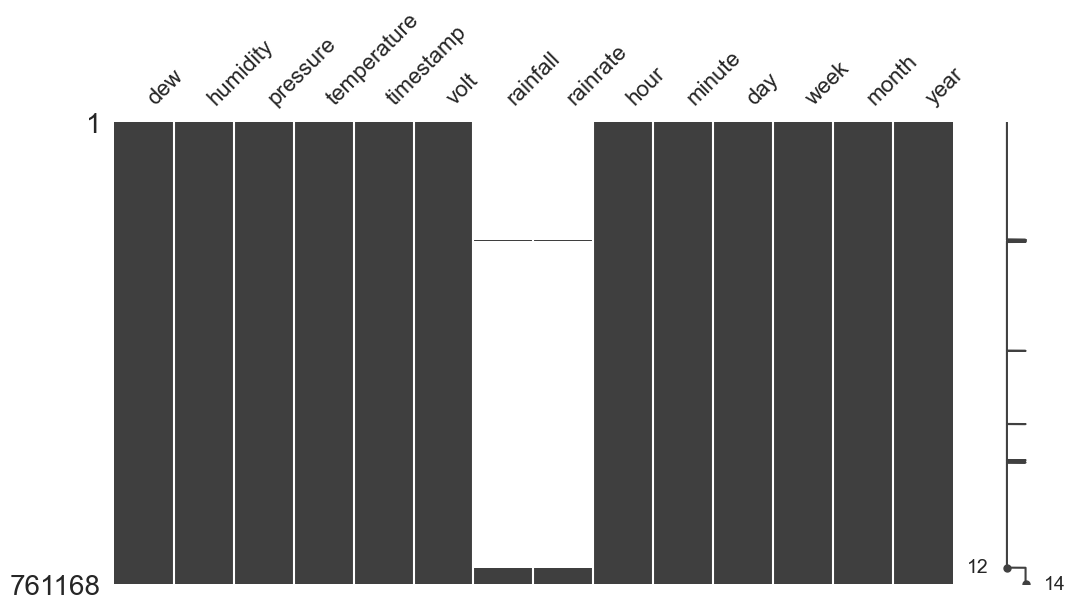


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 732012

Contoh baris dengan null:
     dew  humidity  pressure  temperature                 timestamp  volt  \
0  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00  4.07   
1  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00  4.07   
2  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00  4.07   
3  24.73     100.0   1010.79        24.73 2025-01-01 00:01:41+07:00  4.07   
4  24.74     100.0   1010.90        24.74 2025-01-01 00:02:37+07:00  4.07   
5  24.74     100.0   1010.90        24.74 2025-01-01 00:02:41+07:00  4.07   
6  24.74     100.0   1010.85        24.74 2025-01-01 00:03:37+07:00  4.07   
7  24.74     100.0   1010.85        24.74 2025-01-01 00:03:41+07:00  4.07   
8  24.73     100.0   1010.86        24.73 2025-01-01 00:04:37+07:00  4.07   
9  24.73     100.0   1010.86        24.73 2025-01-01 00:04:41+07:00  4.07   

   rainfall  rainrate  hour  minute  day  week  month  year

In [38]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca3 ===\n")
print(cuaca3.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca3.isnull().sum() / len(cuaca3)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca3, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca3[cuaca3.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

=== Informasi Missing Values dalam cuaca5 ===

dew                 0
humidity            0
pressure            0
rainfall           71
rainrate           71
temperature         0
timestamp           0
volt              277
tips           595374
rain_rate      708550
hour                0
minute              0
day                 0
week                0
month               0
year                0
dtype: int64


=== Persentase Missing Values ===

dew             0.000000
humidity        0.000000
pressure        0.000000
rainfall        0.010000
rainrate        0.010000
temperature     0.000000
timestamp       0.000000
volt            0.039015
tips           83.857501
rain_rate      99.798164
hour            0.000000
minute          0.000000
day             0.000000
week            0.000000
month           0.000000
year            0.000000
dtype: float64


=== Visualisasi Missing Values ===


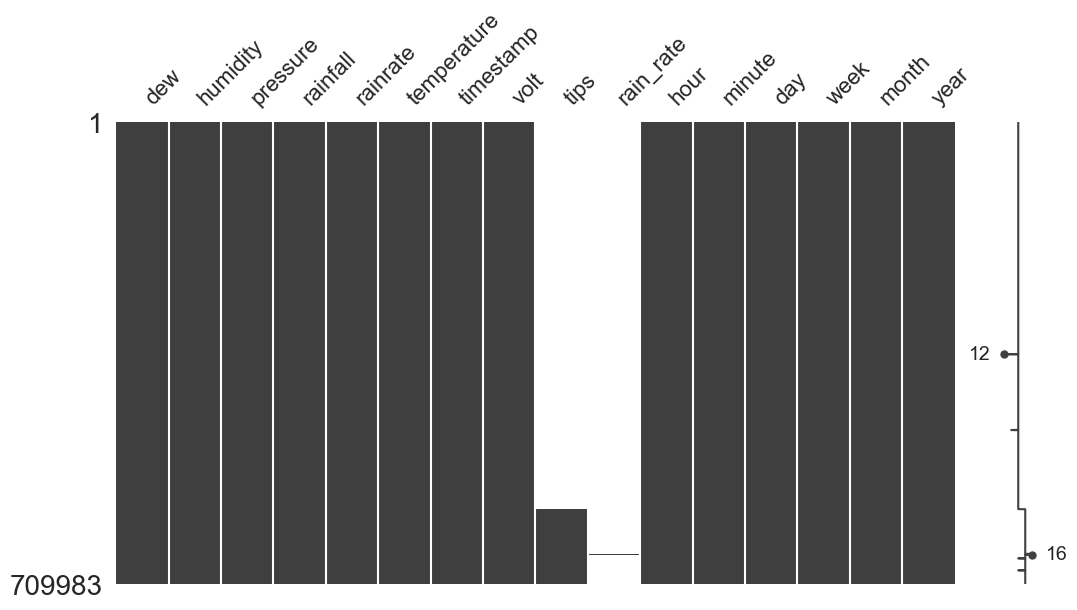


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 708550

Contoh baris dengan null:
        dew  humidity  pressure  rainfall  rainrate  temperature  \
0  27.74858  97.23300  1011.023   11.7348       0.0     28.23109   
1  27.58560  96.49294  1011.033   11.7348       0.0     28.19905   
2  27.56910  96.34035  1011.045   11.7348       0.0     28.20973   
3  27.68267  96.81529  1011.038   11.7348       0.0     28.23911   
4  27.71058  96.92783  1011.046   11.7348       0.0     28.24712   
5  27.70560  96.80957  1011.059   11.7348       0.0     28.26315   
6  27.63344  96.49294  1011.047   11.7348       0.0     28.24712   
7  27.46198  95.62127  1011.058   11.7348       0.0     28.23109   
8  27.59813  96.20493  1011.048   11.7348       0.0     28.26315   
9  27.58824  96.22400  1011.041   11.7348       0.0     28.24979   

                  timestamp     volt  tips  rain_rate  hour  minute  day  \
0 2025-03-19 13:41:37+07:00  4.20625   NaN        NaN    13      41   19   
1 2025

In [39]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca5 ===\n")
print(cuaca5.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca5.isnull().sum() / len(cuaca5)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca5, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca5[cuaca5.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_station_trends(data_dict, column_to_plot, freq='d', agg_method='mean'):
    """
    Membuat plot tren perbandingan dengan metode agregasi dinamis.

    Args:
        data_dict (dict): Dictionary {station_id: DataFrame}.
        column_to_plot (str): Nama kolom (misal: 'temperature', 'rain_mm').
        freq (str): 'd' (Harian), 'h' (Jam), 'min' (Menit).
        agg_method (str): Metode statistik ('mean', 'median', 'max', 'min', 'sum').
                          Default adalah 'mean'.
    """
    
    # 1. Konfigurasi Label Frekuensi
    freq_config = {
        'd': {'label': 'Harian', 'xlabel': 'Tanggal', 'code': 'd'}, # code: alias pandas
        'h': {'label': 'Per Jam', 'xlabel': 'Waktu (Jam)', 'code': 'h'},
        'min': {'label': 'Per Menit', 'xlabel': 'Waktu (Menit)', 'code': 'min'}
    }
    
    # Ambil config, default ke Harian jika typo
    selected_freq = freq_config.get(freq, freq_config['d'])
    
    # 2. Konfigurasi Label Agregasi (Biar judul grafik bahasa Indonesia)
    agg_labels = {
        'mean': 'Rata-rata',
        'median': 'Median (Nilai Tengah)',
        'max': 'Maksimum (Tertinggi)',
        'min': 'Minimum (Terendah)',
        'sum': 'Total Akumulasi'
    }
    # Ambil label indo, kalau gak ada pakai teks aslinya (misal 'std')
    agg_display_name = agg_labels.get(agg_method, agg_method.capitalize())

    # Mulai Plotting
    plt.figure(figsize=(15, 7))

    # Loop stasiun
    for station_id, df in data_dict.items():
        if column_to_plot not in df.columns:
            print(f"⚠️ Peringatan: Kolom '{column_to_plot}' tidak ada di {station_id}. Skip.")
            continue

        temp_df = df.copy()
        
        # Pastikan timestamp adalah datetime
        if not pd.api.types.is_datetime64_any_dtype(temp_df['timestamp']):
             temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

        # 3. PROSES GROUPING & AGREGASI DINAMIS
        # Kita buat kolom bantuan untuk grouping waktu
        time_col = f'time_group_{freq}'
        
        # dt.floor membulatkan waktu ke bawah (misal 13:45 -> 13:00 untuk jam)
        temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
        
        # INI BAGIAN KUNCI: .agg(agg_method) menggantikan .mean()
        # agg_method bisa berisi string: 'mean', 'sum', 'max', dll.
        trend_data = temp_df.groupby(time_col)[column_to_plot].agg(agg_method).reset_index()

        # Plotting
        plt.plot(trend_data[time_col], trend_data[column_to_plot], label=station_id, alpha=0.8)

    # 4. Mempercantik Visualisasi
    plt.xlabel(selected_freq['xlabel'], fontsize=12)
    plt.ylabel(f"{agg_display_name} {column_to_plot.replace('_', ' ').capitalize()}", fontsize=12)
    
    plt.title(f"Perbandingan {agg_display_name} {column_to_plot} ({selected_freq['label']})", 
              fontsize=14, fontweight='bold')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.show()

Menampilkan plot perbandingan per jam...


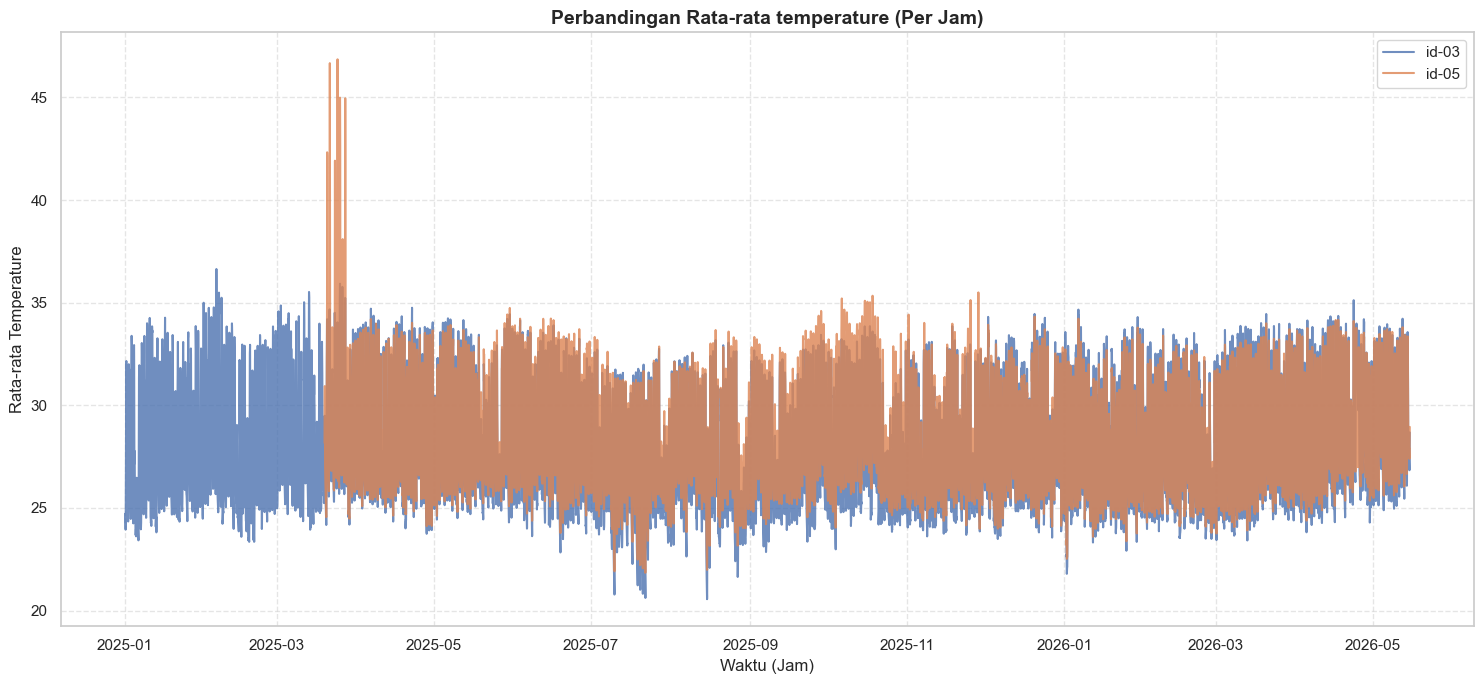

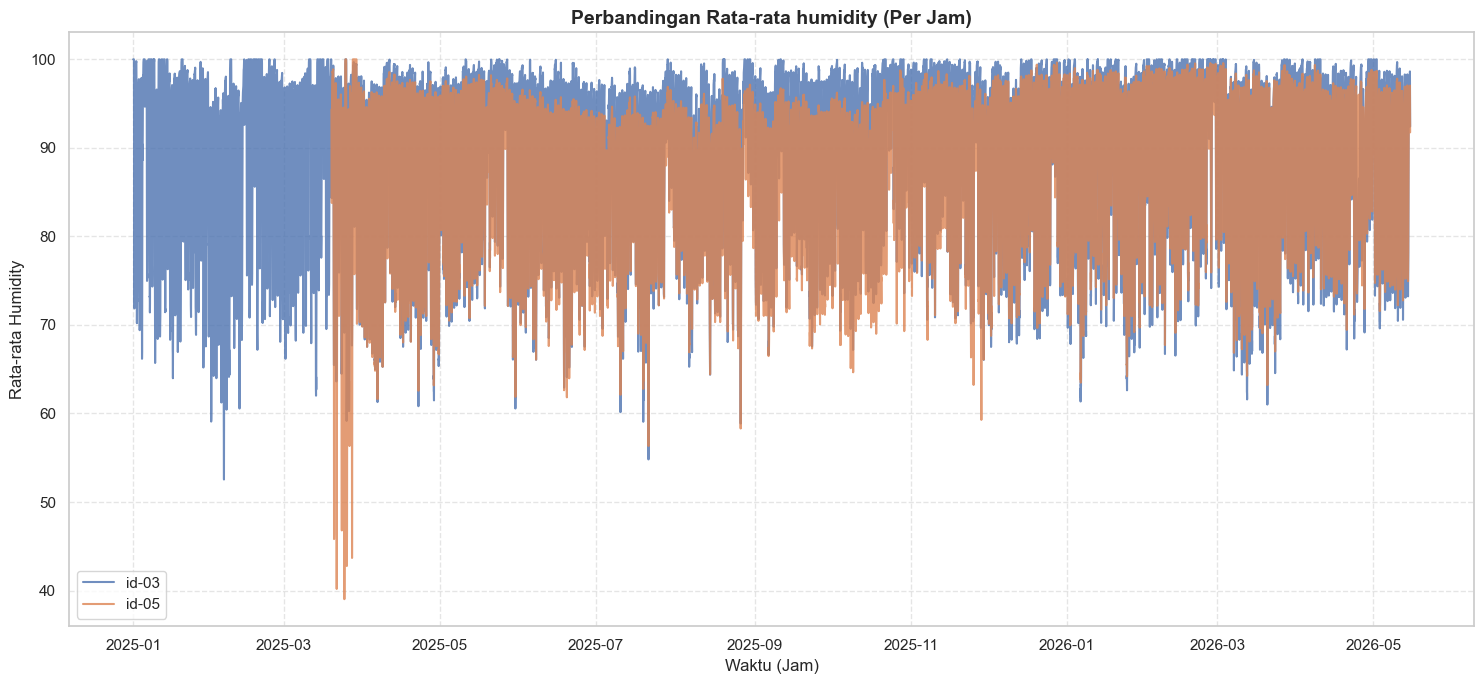

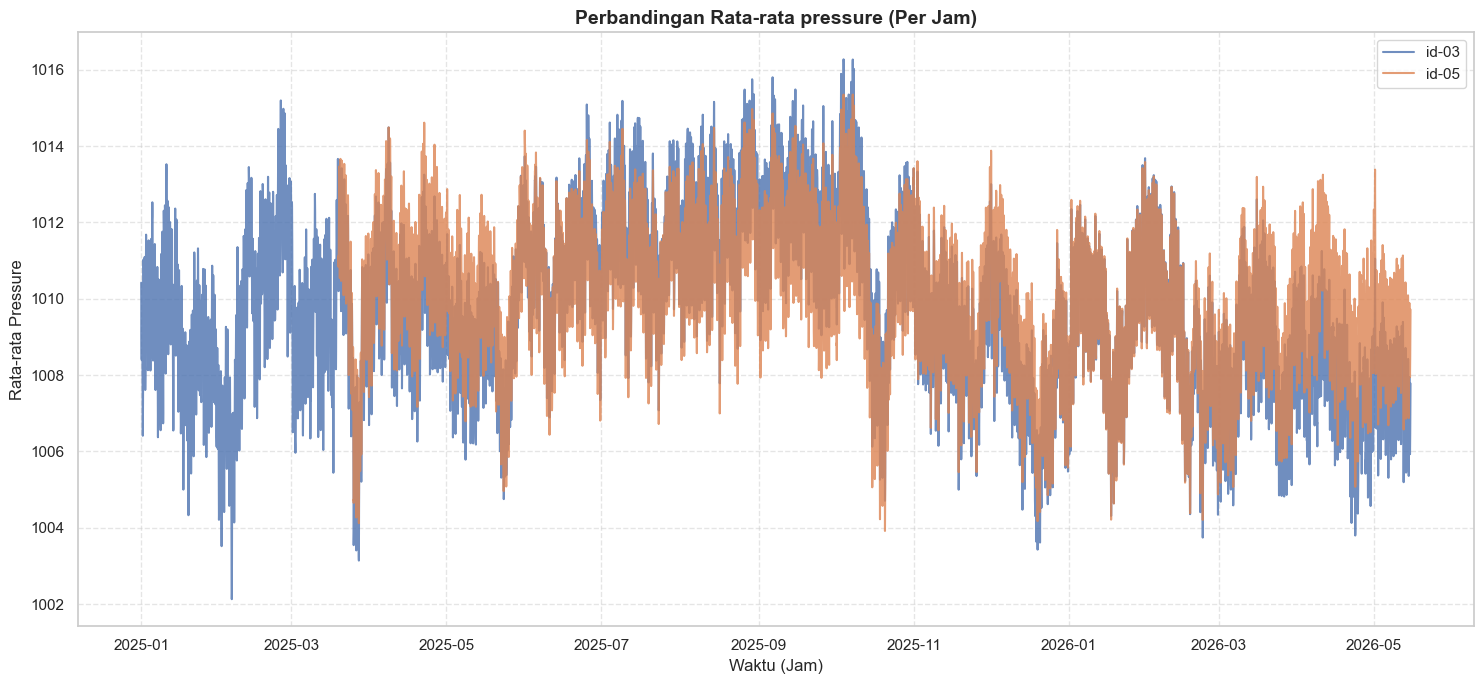

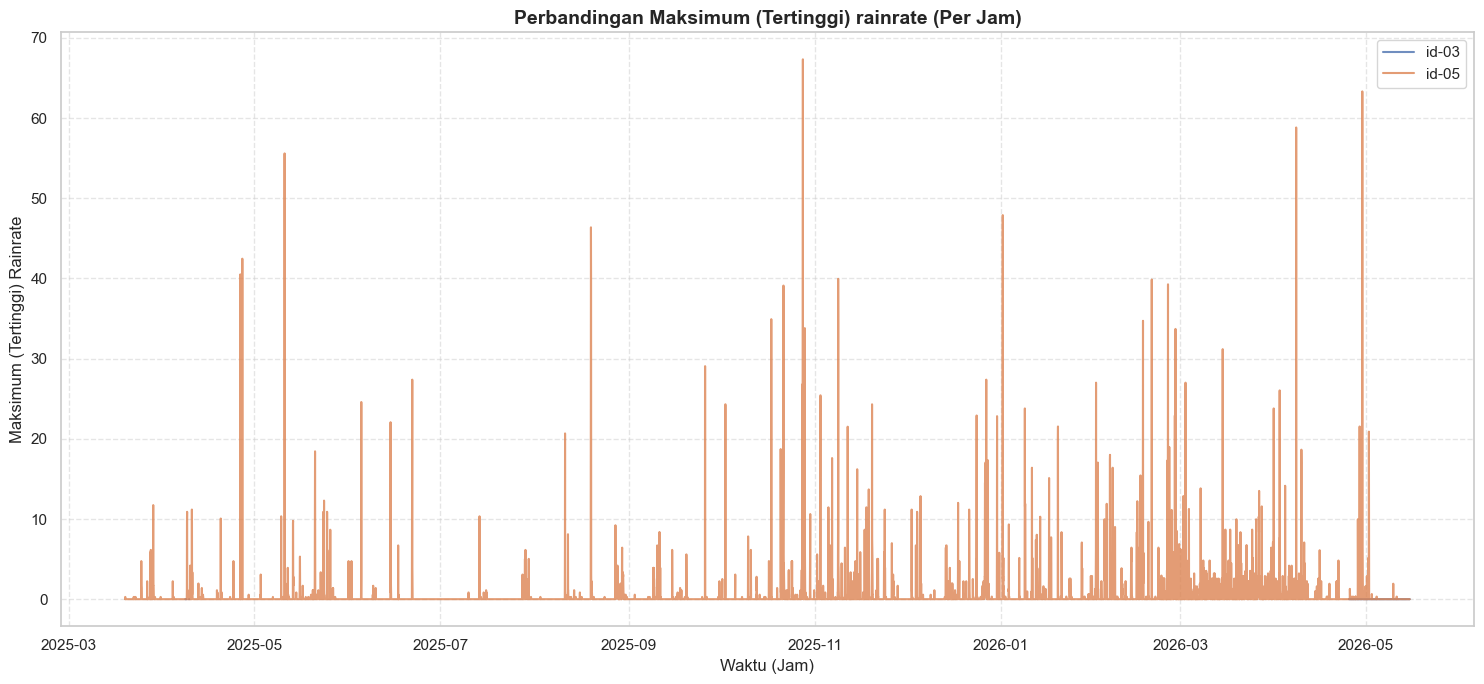

In [41]:
# --- 1. Membuat Plot Rata-rata PER JAM ---
# Cukup atur freq='h'
print("Menampilkan plot perbandingan per jam...")
plot_station_trends(weather_dataframes, 'temperature', freq='h', agg_method='mean')
plot_station_trends(weather_dataframes, 'humidity', freq='h', agg_method='mean')
plot_station_trends(weather_dataframes, 'pressure', freq='h', agg_method='mean')
plot_station_trends(weather_dataframes, 'rainrate', freq='h', agg_method='max')


Menampilkan plot perbandingan per hari...


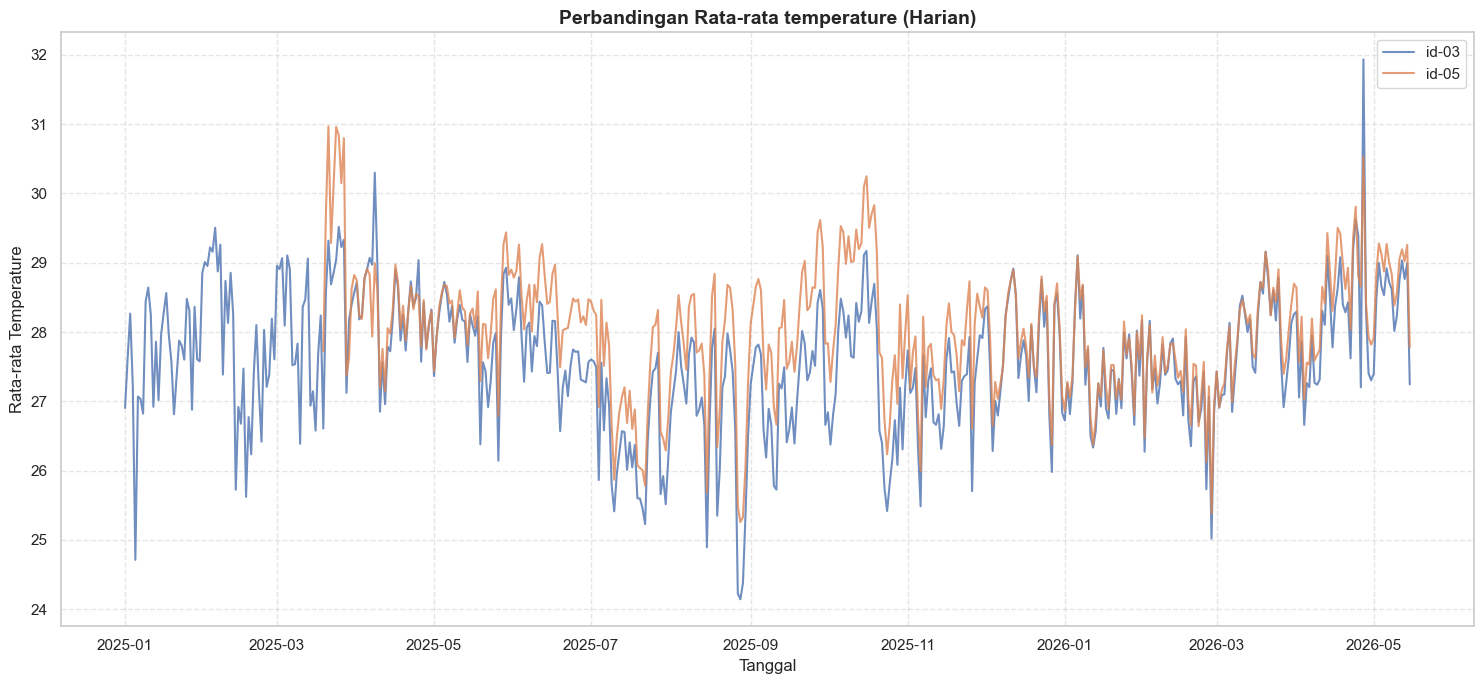

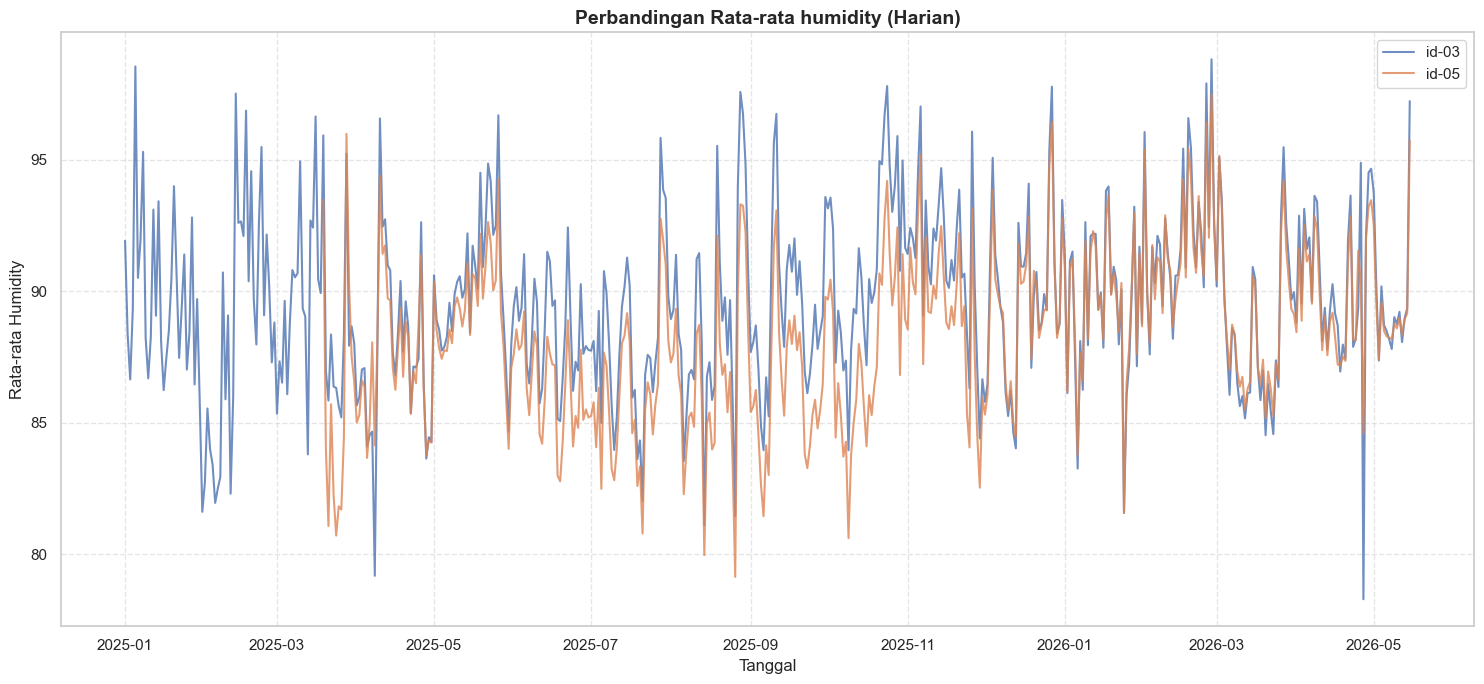

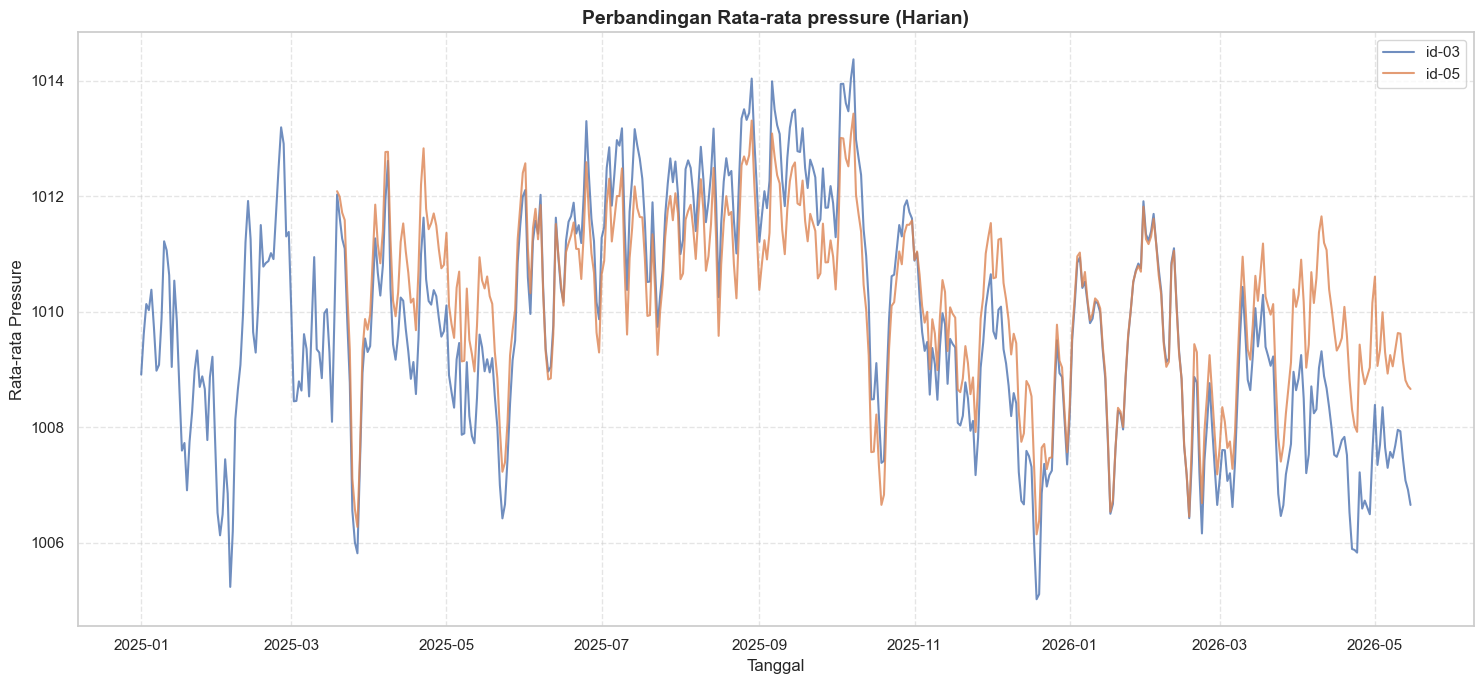

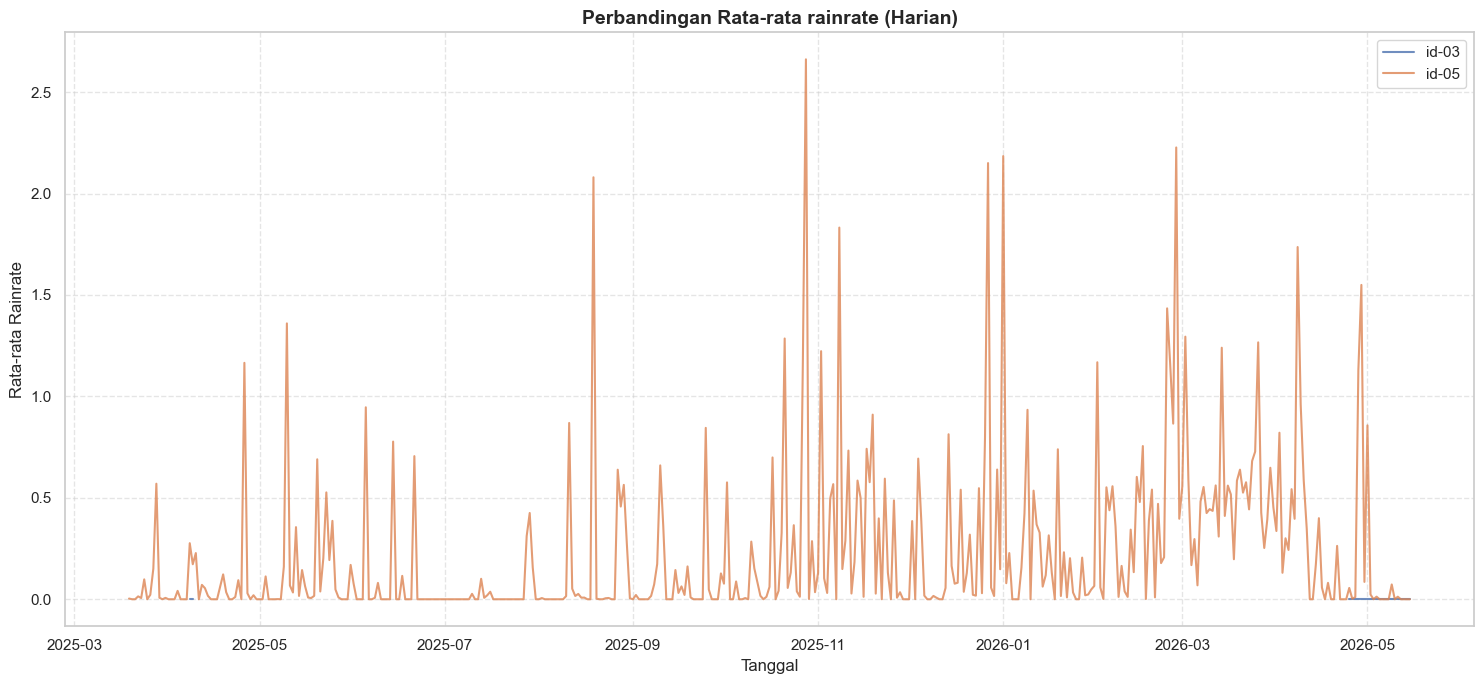

In [42]:
# --- 2. Membuat Plot Rata-rata PER HARI ---
# Gunakan nilai default freq='d' atau tulis secara eksplisit
print("\nMenampilkan plot perbandingan per hari...")
plot_station_trends(weather_dataframes, 'temperature', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'humidity', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'pressure', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'rainrate', freq='d', agg_method='mean')

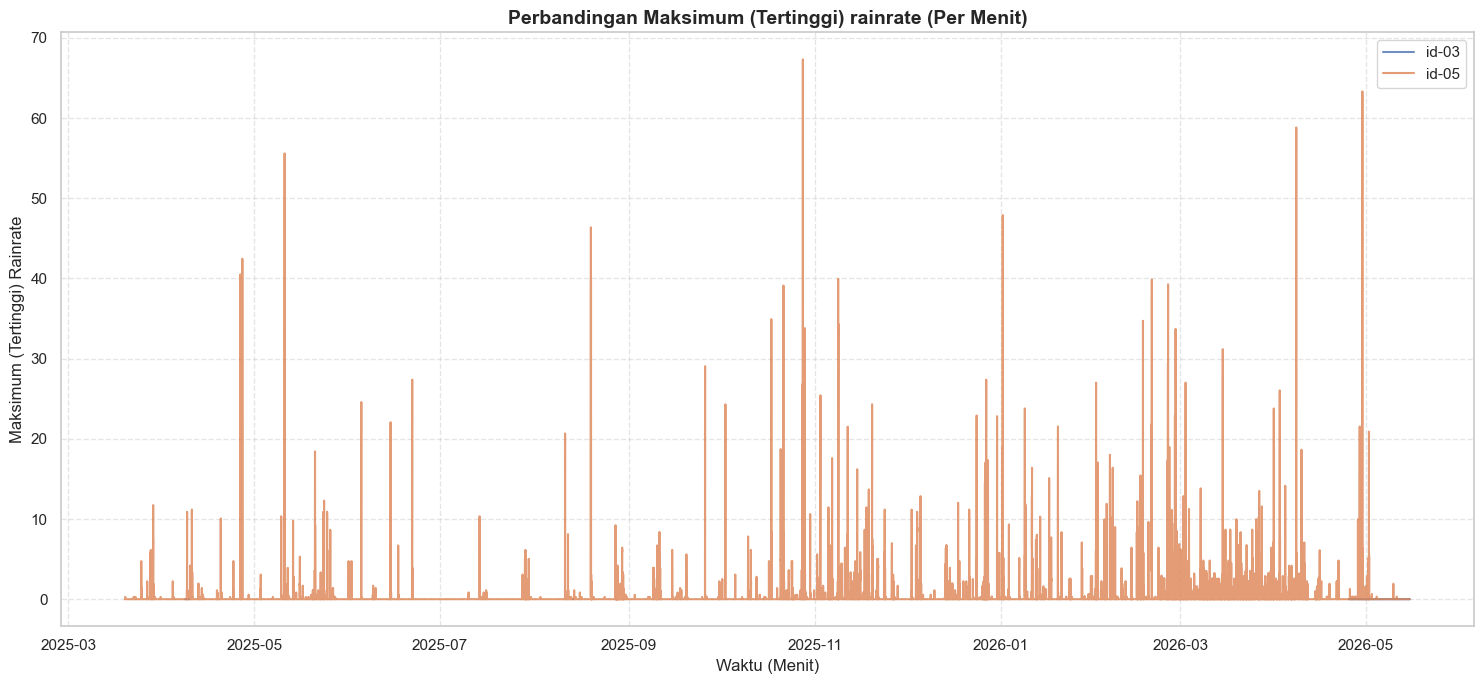

In [43]:
plot_station_trends(weather_dataframes, 'rainrate', freq='min', agg_method='max')

--- PENGUJIAN KONSTANTA: 0.2794 mm/tip ---
Rata-rata penyimpangan dari bilangan bulat: 0.1347


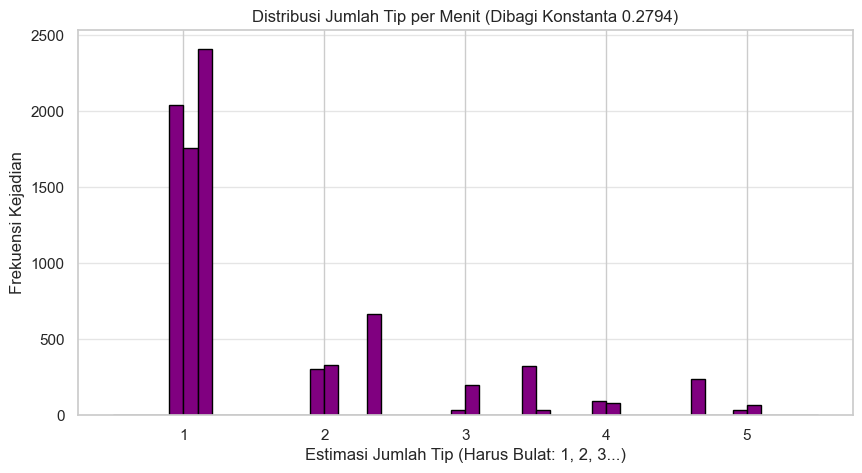

In [44]:
# Pastikan data urut waktu
cuaca5 = cuaca5.sort_values('timestamp').reset_index(drop=True)

# 1. HITUNG DELTA (Hujan per menit/interval)
# Kita gunakan .diff() untuk mencari selisih dari baris sebelumnya
cuaca5['delta_rain'] = cuaca5['rainfall'].diff()

# Bersihkan nilai negatif (anggap 0 karena itu reset/noise turun)
cuaca5['delta_rain'] = cuaca5['delta_rain'].clip(lower=0)

# 2. TENTUKAN KONSTANTA (Coba salah satu yang Anda sebutkan)
# Silakan ganti angka ini: 0.2, 0.2794, atau 0.32125
KONSTANTA_TIP = 0.2794  # <-- Ganti sesuai spesifikasi alat Anda!

# 3. HITUNG JUMLAH TIP (ESTIMASI)
cuaca5['estimated_tips'] = cuaca5['delta_rain'] / KONSTANTA_TIP

# 4. CEK APAKAH HASILNYA BULAT? (VALIDASI)
# Kita ambil hanya data yang hujannya > 0
data_hujan = cuaca5[cuaca5['delta_rain'] > 0].copy()

# Hitung sisa pembagian (Residual) dari bilangan bulat terdekat
# Contoh: Jika hasil 1.01 -> sisa 0.01 (Bagus)
#         Jika hasil 1.50 -> sisa 0.50 (Jelek/Salah Konstanta)
data_hujan['jarak_ke_bulat'] = np.abs(data_hujan['estimated_tips'] - np.round(data_hujan['estimated_tips']))

print(f"--- PENGUJIAN KONSTANTA: {KONSTANTA_TIP} mm/tip ---")
print(f"Rata-rata penyimpangan dari bilangan bulat: {data_hujan['jarak_ke_bulat'].mean():.4f}")

# 5. VISUALISASI HISTOGRAM TIP
# Jika konstantanya BENAR, grafik akan menumpuk di angka 1.0, 2.0, 3.0
# Jika konstantanya SALAH, grafik akan menyebar acak
plt.figure(figsize=(10, 5))
plt.hist(data_hujan['estimated_tips'], bins=50, range=(0.5, 5.5), color='purple', edgecolor='black')
plt.title(f'Distribusi Jumlah Tip per Menit (Dibagi Konstanta {KONSTANTA_TIP})')
plt.xlabel('Estimasi Jumlah Tip (Harus Bulat: 1, 2, 3...)')
plt.ylabel('Frekuensi Kejadian')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.5)
plt.show()

In [45]:
data_hujan.tail(100)

,dew,humidity,pressure,rainfall,rainrate,temperature,timestamp,volt,tips,rain_rate,hour,minute,day,week,month,year,delta_rain,estimated_tips,jarak_ke_bulat
689170,28.58909,83.78218,1008.52,0.3215,0.3215,31.68116,2026-04-30 13:22:03+07:00,3.93500,1.0,NaN,13,22,30,18,4,2026,0.3215,1.15068,0.15068
689514,26.21976,95.42863,1011.08,0.6430,0.3215,27.01610,2026-04-30 19:10:03+07:00,3.92625,1.0,NaN,19,10,30,18,4,2026,0.3215,1.15068,0.15068
689520,26.19078,95.40002,1011.14,0.9645,0.6430,26.99207,2026-04-30 19:16:03+07:00,3.92750,2.0,NaN,19,16,30,18,4,2026,0.3215,1.15068,0.15068
689528,26.22205,95.80057,1011.35,1.2860,0.9645,26.95201,2026-04-30 19:24:03+07:00,3.93000,3.0,NaN,19,24,30,18,4,2026,0.3215,1.15068,0.15068
689536,26.20618,95.93599,1011.66,1.6075,1.2860,26.91196,2026-04-30 19:32:03+07:00,3.96500,4.0,NaN,19,32,30,18,4,2026,0.3215,1.15068,0.15068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702285,26.58064,94.48066,1010.97,0.9645,0.9645,27.55016,2026-05-09 22:03:51+07:00,3.88250,3.0,NaN,22,3,9,19,5,2026,0.3215,1.15068,0.15068
702286,26.67972,95.23979,1010.96,1.2860,1.2860,27.51278,2026-05-09 22:04:51+07:00,3.87500,4.0,NaN,22,4,9,19,5,2026,0.3215,1.15068,0.15068
702289,26.61740,95.24742,1010.97,1.6075,1.6075,27.44869,2026-05-09 22:07:51+07:00,3.86625,5.0,NaN,22,7,9,19,5,2026,0.3215,1.15068,0.15068
702295,26.53981,95.18448,1010.98,1.9290,1.9290,27.38193,2026-05-09 22:13:51+07:00,3.84625,6.0,NaN,22,13,9,19,5,2026,0.3215,1.15068,0.15068


In [46]:
cuaca5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 709983 entries, 0 to 709982
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype                       
---  ------          --------------   -----                       
 0   dew             709983 non-null  float64                     
 1   humidity        709983 non-null  float64                     
 2   pressure        709983 non-null  float64                     
 3   rainfall        709912 non-null  float64                     
 4   rainrate        709912 non-null  float64                     
 5   temperature     709983 non-null  float64                     
 6   timestamp       709983 non-null  datetime64[ns, Asia/Jakarta]
 7   volt            709706 non-null  float64                     
 8   tips            114609 non-null  float64                     
 9   rain_rate       1433 non-null    float64                     
 10  hour            709983 non-null  int32                       
 11  minute       

In [47]:
import pandas as pd
import numpy as np

# 1. PERSIAPAN
df_proses = cuaca5.copy()
if 'timestamp' in df_proses.columns:
    df_proses = df_proses.set_index('timestamp')
df_proses = df_proses.sort_index()

# ==========================================
# 2. SETRIKA DATA (MEMBERSIHKAN GLITCH TURUN)
# ==========================================
# Kita buat kolom baru agar data asli tidak rusak
df_proses['rainfall_clean'] = df_proses['rainfall'].copy()
delta_kotor = df_proses['rainfall'].diff()

# Logika Emas: Jika data tiba-tiba turun (delta < 0), 
# TAPI angkanya tidak jatuh ke angka kecil (misal masih > 0.5 mm), 
# itu PASTI noise/glitch (Poin 1 Anda), BUKAN reset.
mask_glitch_turun = (delta_kotor < 0) & (df_proses['rainfall'] > 0.5)

# Jadikan NaN, lalu "Setrika" (Forward Fill) dengan nilai menit sebelumnya
df_proses.loc[mask_glitch_turun, 'rainfall_clean'] = np.nan
df_proses['rainfall_clean'] = df_proses['rainfall_clean'].ffill()

# ==========================================
# 3. HITUNG SELISIH DARI DATA YANG SUDAH BERSIH
# ==========================================
df_proses['rain_actual_minute'] = df_proses['rainfall_clean'].diff()

# ==========================================
# 4. FIX RESET ASLI (Poin 2 Anda)
# ==========================================
# Karena glitch sudah disetrika di langkah 2, 
# jika sekarang masih ada delta < 0, itu 100% adalah Reset Asli (Jatuh ke 0).
mask_reset_asli = df_proses['rain_actual_minute'] < 0

# Hujan murni tepat di menit reset itu adalah sisa air di ember saat itu
df_proses.loc[mask_reset_asli, 'rain_actual_minute'] = df_proses.loc[mask_reset_asli, 'rainfall_clean']

# ==========================================
# 5. FIX LONJAKAN KE ATAS (GLITCH NAIK)
# ==========================================
BATAS_MAKSIMAL_PER_MENIT = 10.0  # mm
mask_ngawur = df_proses['rain_actual_minute'] > BATAS_MAKSIMAL_PER_MENIT
df_proses.loc[mask_ngawur, 'rain_actual_minute'] = 0 

# Bersihkan sisa NaN di baris paling pertama
df_proses['rain_actual_minute'] = df_proses['rain_actual_minute'].fillna(0)
# Pastikan mutlak tidak ada angka minus
df_proses['rain_actual_minute'] = df_proses['rain_actual_minute'].clip(lower=0)

# ==========================================
# 6. RESAMPLE KE JAM (Poin 4 Anda)
# ==========================================
# Sekarang kita BISA MENGGUNAKAN SUM DENGAN AMAN!
agg_rules = {
    'rain_actual_minute': 'sum', 
    'temperature': 'mean',
    'humidity': 'mean',
    'pressure': 'mean',
    'dew': 'mean'
}

df_hourly = df_proses.resample('1h').agg(agg_rules)
df_hourly = df_hourly.rename(columns={'rain_actual_minute': 'rain_mm'})

# Cek apakah angka 70 mm gaib itu sudah hilang
print(f"\nMax Hujan per Jam (Setelah Di-Setrika): {df_hourly['rain_mm'].max():.2f} mm")


Max Hujan per Jam (Setelah Di-Setrika): 93.23 mm


In [48]:
df_hourly.tail(100)

,rain_mm,temperature,humidity,pressure,dew
timestamp,,,,,
2026-05-11 05:00:00+07:00,0.0,26.182384,97.257426,1009.656607,25.711506
2026-05-11 06:00:00+07:00,0.0,26.187406,97.391621,1010.171270,25.739715
2026-05-11 07:00:00+07:00,0.0,27.102726,95.194342,1010.632712,26.262506
2026-05-11 08:00:00+07:00,0.0,28.668587,89.552662,1010.762667,26.769856
2026-05-11 09:00:00+07:00,0.0,30.379377,83.064085,1010.602593,27.162866
...,...,...,...,...,...
2026-05-15 04:00:00+07:00,0.0,27.561305,96.157144,1008.150862,26.891317
2026-05-15 05:00:00+07:00,0.0,27.390391,96.622422,1008.484333,26.803441
2026-05-15 06:00:00+07:00,0.0,27.438190,97.035049,1008.975833,26.923633


C:\Users\acer\AppData\Local\Temp\ipykernel_18324\1737085646.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


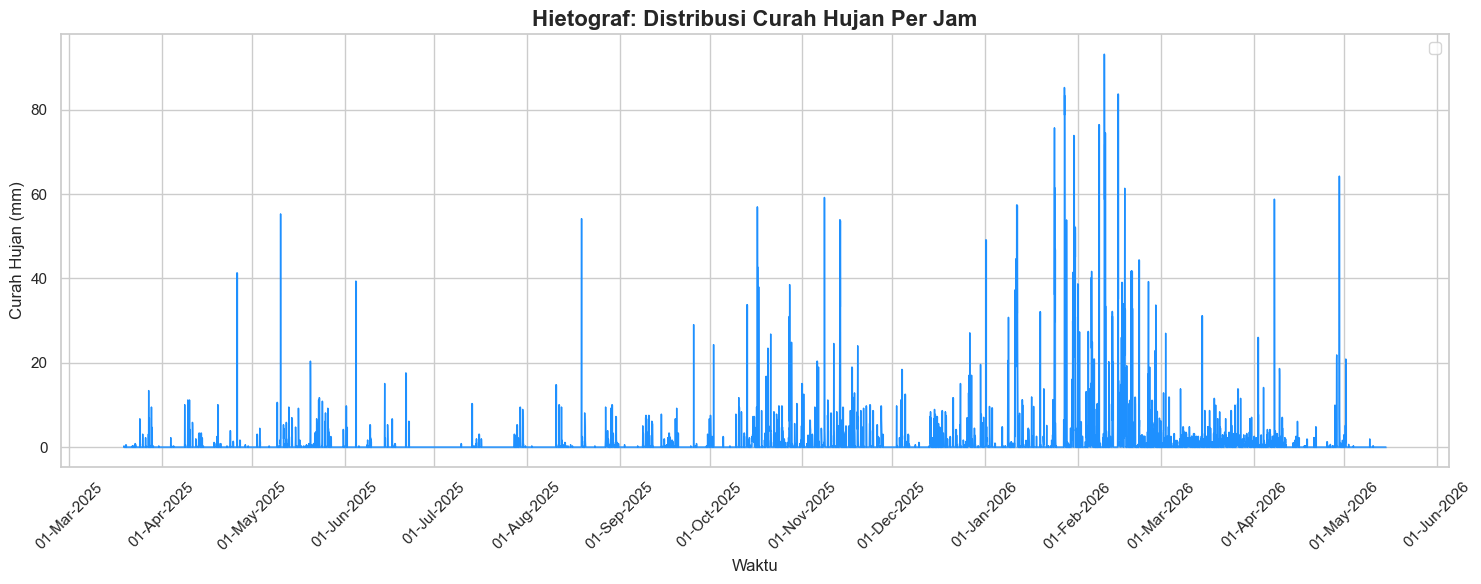

In [49]:
# Set Style biar ganteng
sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# A. PLOT DATA
# Kita pakai bar plot, tapi karena indexnya datetime, kita atur width-nya
# Width 0.03 hari (sekitar 45 menit) biar ada celah dikit antar jam
#plt.bar(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', width=1, label='Curah Hujan (mm/jam)')

# Alternatif kalau data sangat padat (tahunan), pakai ini:
plt.plot(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', lw=1)
plt.fill_between(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', alpha=0.3)

# B. PERCANTIK
plt.title('Hietograf: Distribusi Curah Hujan Per Jam', fontsize=16, fontweight='bold')
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.xlabel('Waktu', fontsize=12)
plt.legend(loc='upper right')

# Format Tanggal di Sumbu X biar rapi
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Label per bulan
plt.xticks(rotation=45)

# Batas Y (opsional, biar kelihatan ruang atasnya)
# plt.ylim(0, df_hourly['rain_mm'].max() * 1.2) 

plt.tight_layout()
plt.show()

In [50]:
waktu_puncak = df_hourly['rain_mm'].idxmax()
nilai_puncak = df_hourly['rain_mm'].max()

print(f"Hujan terderas terjadi pada: {waktu_puncak}")
print(f"Sebesar: {nilai_puncak} mm")

Hujan terderas terjadi pada: 2026-02-10 05:00:00+07:00
Sebesar: 93.23499999999999 mm


In [51]:
# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
PATH_FILE_DESA = 'D:\Github\Catatan_Meteorologi\Analisis_Meteorologi\open_meteo_jerukagung\cuaca_jerukagung.csv'

In [52]:
def load_data(filepath):
    if not os.path.exists(filepath):
        print(f"❌ File tidak ditemukan: {filepath}")
        return None
    try:
        df = pd.read_csv(filepath, index_col='date')
        df.index = pd.to_datetime(df.index, utc=True, errors='coerce')
        df.index = df.index.tz_convert('Asia/Jakarta')
        df.index = df.index.tz_localize(None)
        df = df.sort_index()
        return df
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

In [61]:
# 1. Load semua data dulu
df_era5 = load_data(PATH_FILE_DESA)

# ==============================================================================
# 🛠️ TAHAP 1: PERSIAPAN SLICING (Jadikan Naive Sementara)
# ==============================================================================
# Kita ubah dulu ke waktu Jakarta, lalu "copot" labelnya sementara.
# Tujuannya: Agar sintaks slicing .loc['2025'] berjalan mulus tanpa error.

if df_era5.index.tz is not None:
    # 1. Pastikan jamnya sudah digeser ke WIB (+07:00)
    df_era5.index = df_era5.index.tz_convert('Asia/Jakarta')
    
    # 2. HAPUS label zona waktunya sementara
    # Jam 07:00 WIB (+7) akan menjadi jam 07:00 (Polos)
    df_era5.index = df_era5.index.tz_localize(None)

print("Index sementara dikonversi ke Naive (untuk filtering).")

# ==============================================================================
# 🛠️ TAHAP 2: FILTERING & RE-LOCALIZATION (Pasang Lagi Zonanya)
# ==============================================================================

# 1. Ambil data tahun 2025
df_era5 = df_era5.loc['2025':'2026'].copy()

# 2. PASANG KEMBALI ZONA WAKTU ASIA/JAKARTA 
# Karena tadi kita sudah pastikan jamnya benar (langkah Tahap 1.1),
# kita tinggal tempel label 'Asia/Jakarta' lagi.
df_era5.index = df_era5.index.tz_localize('Asia/Jakarta')

print("\n" + "="*40)
print("FILTER BERHASIL & ZONA WAKTU TERPASANG")
print("="*40)
print(f"Zona Waktu: {df_era5.index.tz}") # Harus muncul Asia/Jakarta
print(f"Start     : {df_era5.index.min()}")
print(f"End       : {df_era5.index.max()}")
print(f"Total     : {len(df_era5)} baris")

# Tampilkan data akhir
df_era5.tail(10)

Index sementara dikonversi ke Naive (untuk filtering).

FILTER BERHASIL & ZONA WAKTU TERPASANG
Zona Waktu: Asia/Jakarta
Start     : 2025-01-01 00:00:00+07:00
End       : 2026-05-13 23:00:00+07:00
Total     : 11952 baris


,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_gusts,wind_direction,pressure,sealevel_pressure,sunshine_duration,direct_radiation,cloud_cover
date,,,,,,,,,,,,
2026-05-13 14:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 15:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 16:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 17:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 18:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 19:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 20:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 21:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13 22:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
df_hourly.tail(100)

,rain_mm,temperature,humidity,pressure,dew
timestamp,,,,,
2026-05-11 05:00:00+07:00,0.0,26.182384,97.257426,1009.656607,25.711506
2026-05-11 06:00:00+07:00,0.0,26.187406,97.391621,1010.171270,25.739715
2026-05-11 07:00:00+07:00,0.0,27.102726,95.194342,1010.632712,26.262506
2026-05-11 08:00:00+07:00,0.0,28.668587,89.552662,1010.762667,26.769856
2026-05-11 09:00:00+07:00,0.0,30.379377,83.064085,1010.602593,27.162866
...,...,...,...,...,...
2026-05-15 04:00:00+07:00,0.0,27.561305,96.157144,1008.150862,26.891317
2026-05-15 05:00:00+07:00,0.0,27.390391,96.622422,1008.484333,26.803441
2026-05-15 06:00:00+07:00,0.0,27.438190,97.035049,1008.975833,26.923633


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

def bandingkan_variabel(target_sensor, target_meteo, nama_variabel, satuan, start_time=None, end_time=None):
    """
    Fungsi untuk membandingkan data Sensor vs Open-Meteo dengan filter waktu (opsional)
    Format start_time & end_time: 'YYYY-MM-DD' atau 'YYYY-MM-DD HH:MM:SS'
    """
    print(f"\n" + "="*60)
    print(f"📊 ANALISIS PERBANDINGAN: {nama_variabel.upper()}")
    if start_time or end_time:
        print(f"📅 Periode: {start_time if start_time else 'Awal'} s.d {end_time if end_time else 'Akhir'}")
    print("="*60)

    # 1. SIAPKAN DATA (Merge & Align)
    # Pastikan nama kolom ada
    if target_sensor not in df_hourly.columns:
        print(f"❌ Error: Kolom sensor '{target_sensor}' tidak ditemukan.")
        return
    if target_meteo not in df_era5.columns:
        print(f"❌ Error: Kolom Open-Meteo '{target_meteo}' tidak ditemukan.")
        return

    # Inner Join berdasarkan Index Waktu
    df_compare = pd.merge(
        df_hourly[[target_sensor]], 
        df_era5[[target_meteo]], 
        left_index=True, 
        right_index=True, 
        suffixes=('_sensor', '_satelit')
    )
    
    # --- FILTER WAKTU (BARU) ---
    # Memotong data sesuai batas waktu yang diminta
    if start_time and end_time:
        df_compare = df_compare.loc[start_time:end_time]
    elif start_time:
        df_compare = df_compare.loc[start_time:]
    elif end_time:
        df_compare = df_compare.loc[:end_time]
    
    # Cek apakah data kosong setelah difilter
    if df_compare.empty:
        print("⚠️ Peringatan: Data kosong pada rentang waktu tersebut!")
        return

    # Hapus NaN (jika ada bolong)
    df_compare = df_compare.dropna()
    
    # Ambil Series untuk memudahkan perhitungan
    x = df_compare[f'{target_sensor}_sensor']
    y = df_compare[f'{target_meteo}_satelit']

    # 2. HITUNG STATISTIK ERROR
    mae = mean_absolute_error(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    bias_max = (y - x).max() # Rata-rata selisih (Kampus - Desa)
    bias_min = (y - x).min() # Rata-rata selisih (Kampus - Desa)
    bias = (y - x).mean()    # Rata-rata selisih
    
    # Korelasi
    corr_p = x.corr(y, method='pearson')
    corr_s, _ = spearmanr(x, y)

    print(f"1. Statistik Error:")
    print(f"   - MAE  : {mae:.2f} {satuan}")
    print(f"   - RMSE : {rmse:.2f} {satuan}")
    print(f"   - Bias Max (Kampus - Desa): {bias_max:.2f} {satuan}")
    print(f"   - Bias Min (Kampus - Desa): {bias_min:.2f} {satuan}")
    print(f"   - Bias (Rata-rata Selisih): {bias:.2f} {satuan}")

    print(f"\n2. Statistik Hubungan:")
    print(f"   - Pearson (Linear)    : {corr_p:.4f}")
    print(f"   - Spearman (Ranking)  : {corr_s:.4f}")

    # 3. VISUALISASI
    plt.figure(figsize=(14, 10))

    # --- PLOT A: TIME SERIES (Grafik Garis) ---
    plt.subplot(2, 1, 1)
    df_plot = df_compare 
    
    plt.plot(df_plot.index, df_plot[f'{target_sensor}_sensor'], 
             label=f'Sensor IoT ({target_sensor})', 
             color='blue', 
             alpha=0.8)
    plt.plot(df_plot.index, df_plot[f'{target_meteo}_satelit'], 
             label=f'Open-Meteo ({target_meteo})', 
             color='red', 
             alpha=0.6)
    
    plt.title(f'Time Series: {nama_variabel} (Sensor vs Satelit)', fontsize=14)
    plt.ylabel(f'{nama_variabel} ({satuan})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- PLOT B: SCATTER PLOT (Validasi Linearitas) ---
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=x, y=y, alpha=0.3, color='purple', edgecolor=None)

    # Garis Identitas 1:1
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Garis Sempurna (1:1)')

    # Garis Regresi (Trend Asli)
    sns.regplot(x=x, y=y, scatter=False, color='red', label='Trendline', line_kws={'linestyle':':'})

    plt.xlabel(f'Sensor IoT ({satuan})')
    plt.ylabel(f'Open-Meteo ({satuan})')
    plt.title(f'Scatter Plot: Korelasi {nama_variabel} (r={corr_p:.2f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


📊 ANALISIS PERBANDINGAN: SUHU UDARA
📅 Periode: 2025-01-01 s.d 2025-04-30
1. Statistik Error:
   - MAE  : 1.45 °C
   - RMSE : 2.26 °C
   - Bias Max (Kampus - Desa): 3.11 °C
   - Bias Min (Kampus - Desa): -14.50 °C
   - Bias (Rata-rata Selisih): -1.07 °C

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8625
   - Spearman (Ranking)  : 0.8823


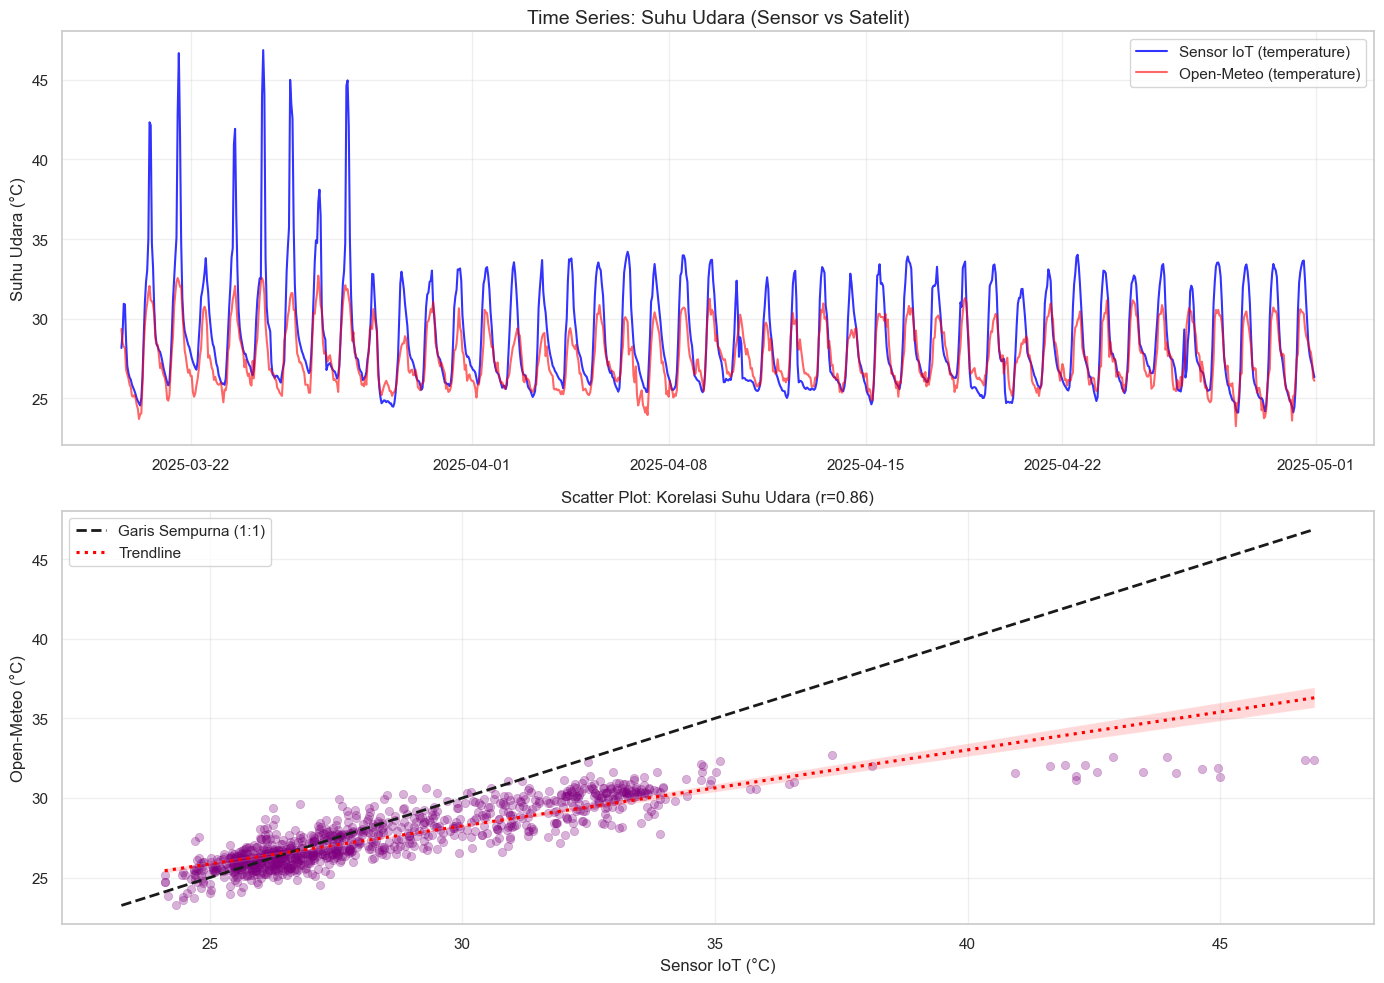


📊 ANALISIS PERBANDINGAN: KELEMBAPAN
📅 Periode: 2025-01-01 s.d 2025-04-30
1. Statistik Error:
   - MAE  : 5.39 %
   - RMSE : 6.65 %
   - Bias Max (Kampus - Desa): 24.90 %
   - Bias Min (Kampus - Desa): -20.84 %
   - Bias (Rata-rata Selisih): -3.13 %

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8684
   - Spearman (Ranking)  : 0.8595


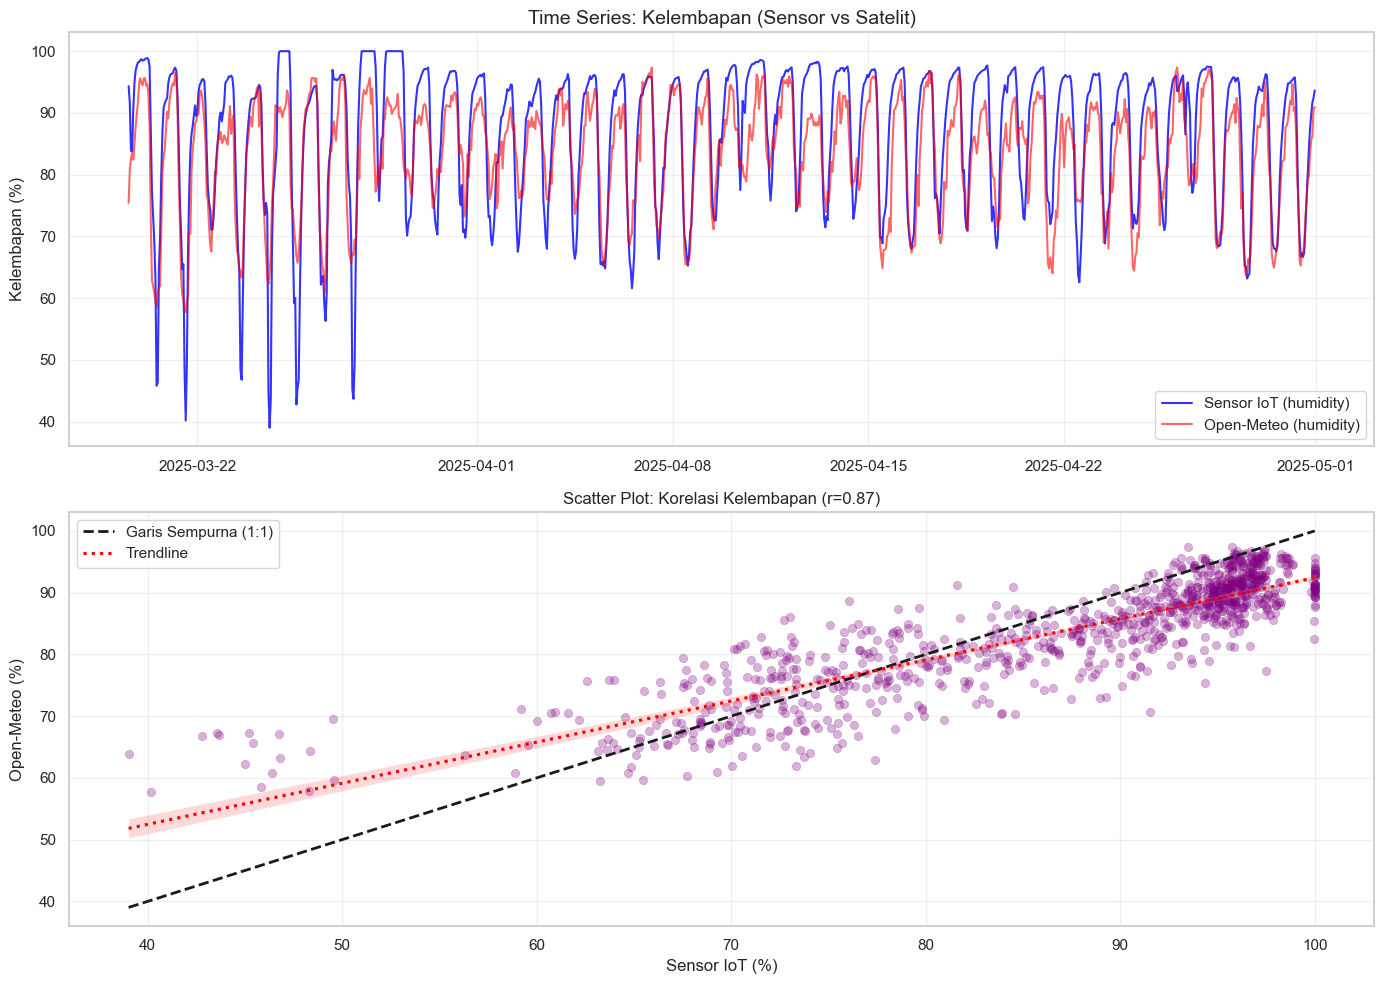


📊 ANALISIS PERBANDINGAN: TEKANAN UDARA
📅 Periode: 2025-01-01 s.d 2025-04-30
1. Statistik Error:
   - MAE  : 2.95 hPa
   - RMSE : 2.99 hPa
   - Bias Max (Kampus - Desa): -1.39 hPa
   - Bias Min (Kampus - Desa): -4.54 hPa
   - Bias (Rata-rata Selisih): -2.95 hPa

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.9656
   - Spearman (Ranking)  : 0.9536


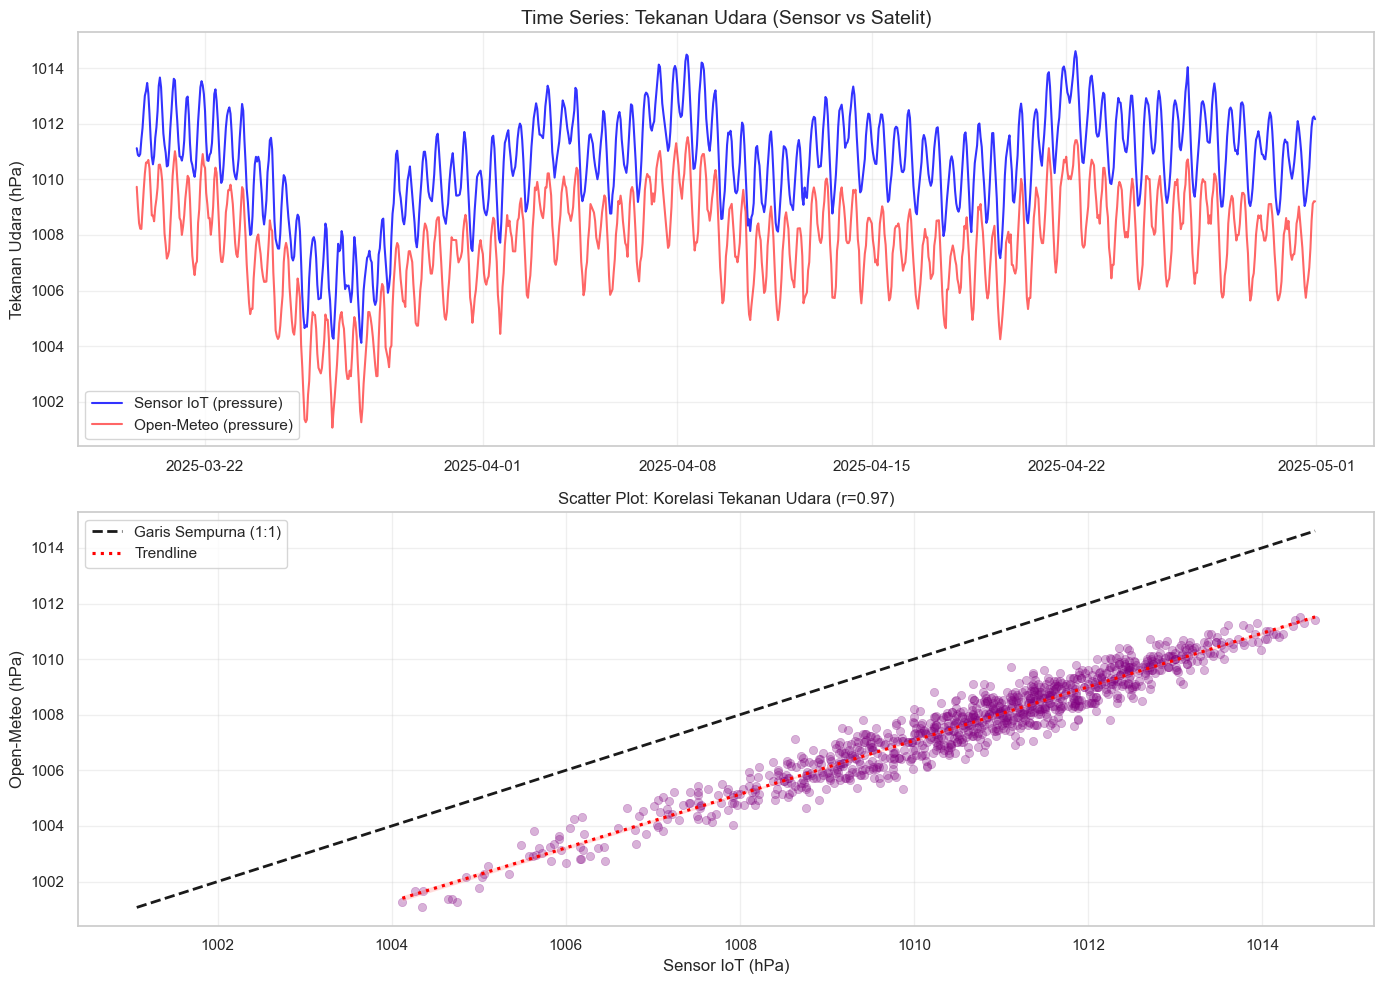


📊 ANALISIS PERBANDINGAN: CURAH HUJAN
📅 Periode: 2025-01-01 00:00:00 s.d 2025-04-30 23:00:00
1. Statistik Error:
   - MAE  : 0.42 mm/jam
   - RMSE : 1.78 mm/jam
   - Bias Max (Kampus - Desa): 7.92 mm/jam
   - Bias Min (Kampus - Desa): -41.35 mm/jam
   - Bias (Rata-rata Selisih): -0.03 mm/jam

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.0259
   - Spearman (Ranking)  : 0.0864


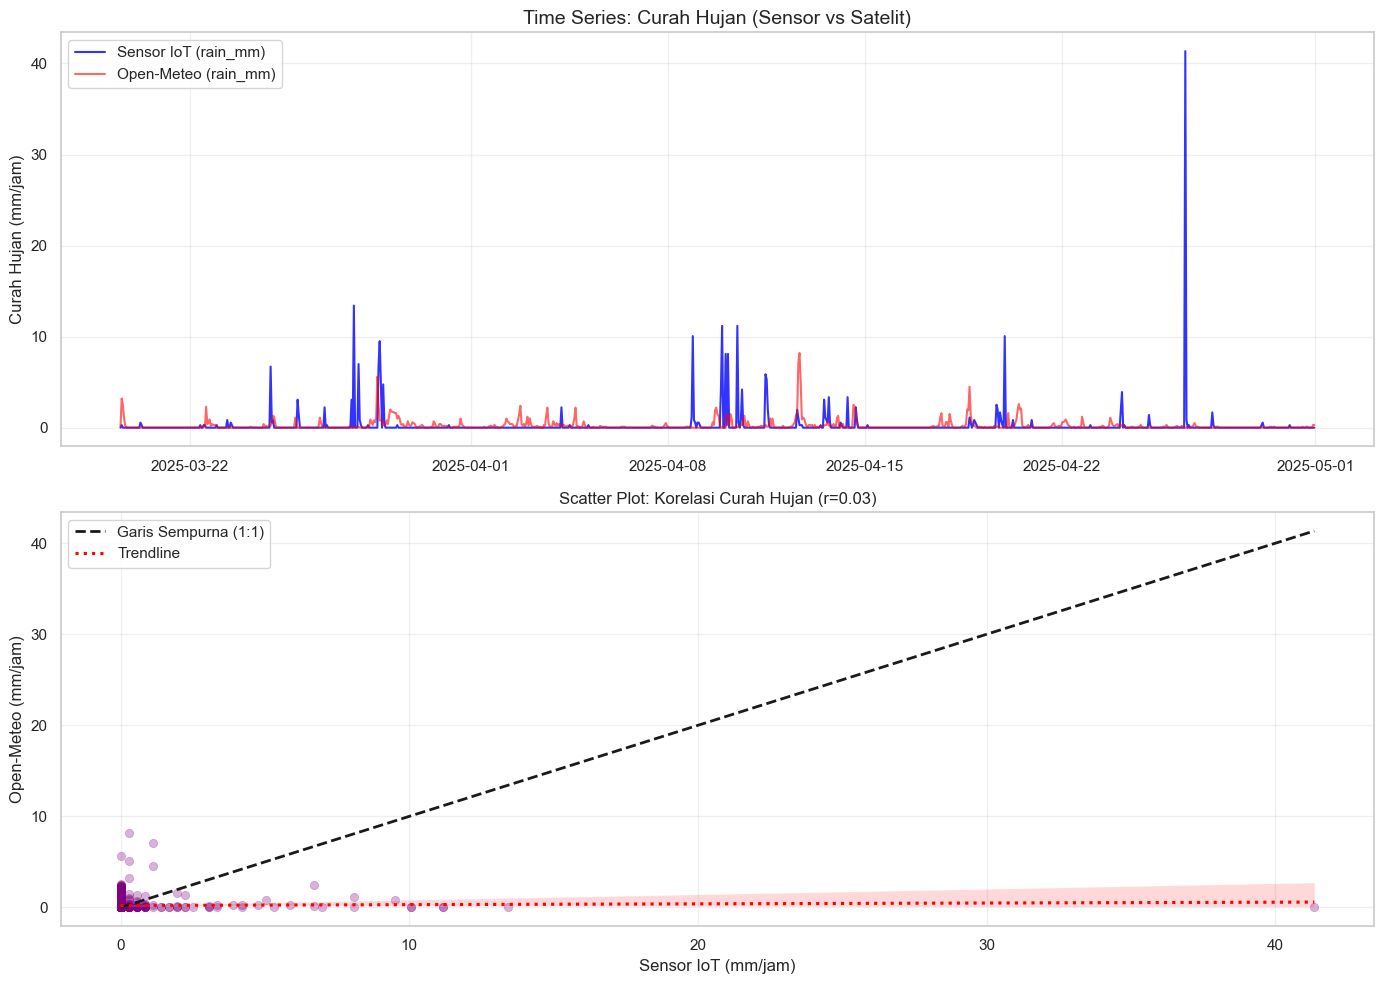

In [63]:
# 1. Tanpa filter waktu (menampilkan semua data seperti sebelumnya)
bandingkan_variabel('temperature', 'temperature', 'Suhu Udara', '°C', start_time='2025-01-01', end_time='2025-04-30')

# 2. Menggunakan start_time (Contoh: Membuang outlier di bulan Maret, mulai analisis dari April 2025)
bandingkan_variabel('humidity', 'humidity', 'Kelembapan', '%', start_time='2025-01-01', end_time='2025-04-30')

# 3. Menggunakan start_time dan end_time (Contoh: Analisis spesifik 1 bulan saja)
bandingkan_variabel('pressure', 'pressure', 'Tekanan Udara', 'hPa', start_time='2025-01-01', end_time='2025-04-30')

# 4. Filter spesifik dengan jam (Contoh: Badai ekstrem dalam 2 hari)
bandingkan_variabel('rain_mm', 'rain_mm', 'Curah Hujan', 'mm/jam', start_time='2025-01-01 00:00:00', end_time='2025-04-30 23:00:00')